In [408]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [409]:
# loading dataset
df = pd.read_csv("Bengaluru_House_Data.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [410]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


# EDA (Exploratory Data Analysis)

In [411]:
# Drop Unwanted columns
cols = ["area_type","availability","society","balcony"]
df = df.drop(cols,axis = 1)

In [412]:
df

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Richards Town,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00


In [413]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [414]:
# Checking null values
df.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [415]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)

In [416]:
df.isnull().sum()

location       1
size          16
total_sqft     0
bath          72
price          0
dtype: int64

In [417]:
# Cleaning location column
df['location'].unique()

# i) remove leading and training spaces
df['location'] = df['location'].str.strip()

df['location'].value_counts()

# ii) handling nan values in location with top 2nd location -- > Sarjapur  Road
df['location'] = df['location'].fillna('Sarjapur  Road')

# iii) Grouping the location with less than 10 houses into others category
# -- check the locations where the value os less than 10
loc = df['location'].value_counts()
loc_less_than_10 = loc[loc<=10]
loc_less_than_10

df['location'] = df['location'].apply(lambda x: "others" if x in loc_less_than_10 else x)

df.location.value_counts()

location
others                  2927
Whitefield               508
Sarjapur  Road           365
Electronic City          275
Thanisandra              226
                        ... 
Tindlu                    11
Banashankari Stage V      11
Doddakallasandra          11
Thyagaraja Nagar          11
HAL 2nd Stage             11
Name: count, Length: 232, dtype: int64

In [418]:
# cleaning size column
df['size'].unique()

# i)Handling nan values in size col
df['size'] = df['size'].fillna("2 BHK")

# ii) Extract only the BHK number and remove unwanted char
df['size'] = df['size'].apply(lambda x: int(x.split()[0]))
df['size'].unique()

# iii)Renaming to size to BHK
df.rename(columns={"size":"bhk"},inplace=True)

In [419]:
# clean total_sqft column
df['total_sqft'].unique()
def clean_total_sqft(sqft):
    try:
        l = sqft.split('-')
        if len(l)==2:
            return (float(l[0])+float(l[1]))/2
        else:
            return float(l[0])
    except:
        return None
        

df['total_sqft'] = df['total_sqft'].apply(clean_total_sqft)

# handling nan values in total_sqft
df['total_sqft'] = df['total_sqft'].fillna(round(df['total_sqft'].mean()))


In [420]:
# cleaning bath column

df["bath"].unique()

# Handling nan values in bath
med = df['bath'].median()
df['bath'] = df['bath'].fillna(med)

df["bath"].unique()

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9.,  8.,  7., 11., 10., 14., 27.,
       12., 16., 40., 15., 13., 18.])

**Handling outliers**

In [421]:
# create a new col price_per_sqft
# formula : price_per_sqft = price/total_sqft

df['price_per_sqft'] = (df['price']*100000)/df['total_sqft']

In [422]:
# Handling outliers in total_sqft
df.describe()
# observation :  in total_sqft col we have houses less that 300 sqft those are outliers
# In real-time houses start with min of 300 sqft

#  formula : total_sqft/bhk > 300 -- > keeps all the realistic total sqft

df = df[df['total_sqft']/df['bhk']>=300]

In [423]:
df.describe()

,bhk,total_sqft,bath,price,price_per_sqft
count,11705.000000,11705.000000,11705.000000,11705.000000,11705.000000
mean,2.666809,1614.029039,2.579667,114.455648,6405.091922
std,0.995743,1296.481391,1.099383,156.421987,4281.960473
min,1.000000,300.000000,1.000000,8.440000,267.829813
25%,2.000000,1120.000000,2.000000,50.000000,4253.521127
50%,3.000000,1314.000000,2.000000,71.000000,5348.837209
75%,3.000000,1720.000000,3.000000,120.000000,7000.000000
max,16.000000,52272.000000,16.000000,3600.000000,176470.588235


All unrealistic tottal_sqft less than 300 got removed

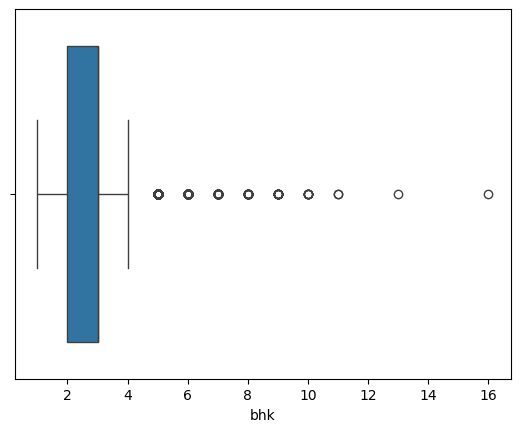

In [424]:
# Handling outliers in bhk column
df['bhk'].unique()
sns.boxplot(x = "bhk",data=df)
df = df[df['bhk']<=6]

In [425]:
# Handling outliers in bath col
df[df["bath"]>df['bhk']+2][["bhk",'bath']]
# observation : Here there are some bath count is suspeciously high compared to bhk number these are outliers

df = df[df["bath"]<df['bhk']+2] # removes outliers(unrealistic valuese where the number of bath count is suspeciously)

<Axes: xlabel='price_per_sqft'>

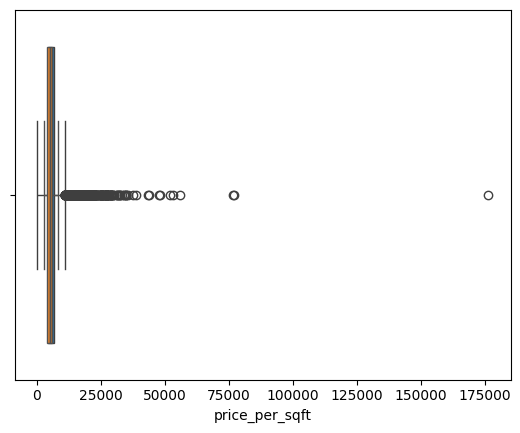

In [426]:
#  handling outliers in price_per_sqft
sns.boxplot(x = "price_per_sqft",data=df)

# IQR Method
q1 = df['price_per_sqft'].quantile(0.25)
q3 = df['price_per_sqft'].quantile(0.75)
IQR = q3 - q1
lower = q1-0.5*IQR
upper = q3+0.5*IQR

df = df[(df['price_per_sqft']>=lower) & (df['price_per_sqft']<=upper)]

sns.boxplot(x = "price_per_sqft",data=df)

In [427]:
# Remove price_per_sqft

df.drop("price_per_sqft",axis = 1,inplace = True)

In [428]:
df.isnull().sum()

location      0
bhk           0
total_sqft    0
bath          0
price         0
dtype: int64

In [429]:
# reset the index

df.reset_index(inplace=True)
df.drop("index",axis = True)

,location,bhk,total_sqft,bath,price
0,Electronic City Phase II,2,1056.0,2.0,39.07
1,Chikka Tirupathi,4,2600.0,5.0,120.00
2,Uttarahalli,3,1440.0,2.0,62.00
3,Lingadheeranahalli,3,1521.0,3.0,95.00
4,Kothanur,2,1200.0,2.0,51.00
...,...,...,...,...,...
9356,Rachenahalli,2,1050.0,2.0,52.71
9357,Bellandur,2,1262.0,2.0,47.00
9358,Green Glen Layout,3,1715.0,3.0,112.00
9359,Whitefield,5,3453.0,4.0,231.00


**Visualization**

Text(0.5, 1.0, 'sqft vs price')

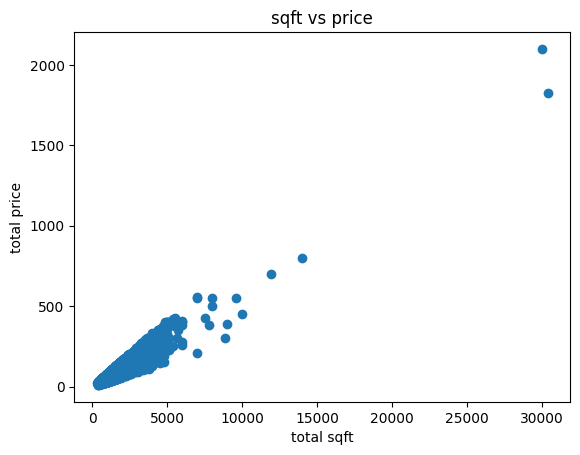

In [430]:
plt.scatter(df["total_sqft"],df["price"])
plt.xlabel("total sqft")
plt.ylabel("total price")
plt.title("sqft vs price")

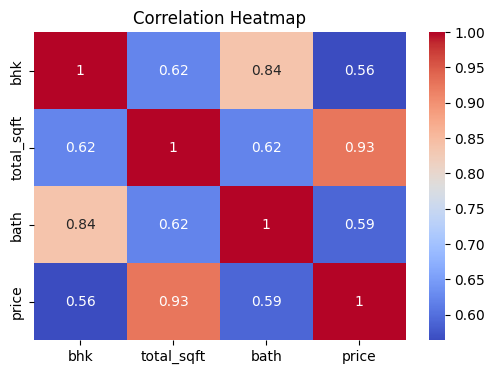

In [431]:
corr_data = df.iloc[:,2:].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_data, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [432]:
# Avg price by location
data = df.groupby("location")["price"].mean().sort_values()
data

location
Kereguddadahalli         34.678571
Dommasandra              37.837500
Bisuvanahalli            40.805000
Anekal                   41.216000
Giri Nagar               42.000000
                           ...    
Hebbal Kempapura        154.363636
Doddaballapur           157.375000
Sector 7 HSR Layout     195.500000
2nd Stage Nagarbhavi    205.000000
Iblur Village           227.250000
Name: price, Length: 231, dtype: float64

**Model Training and Evaluation**

In [433]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score,mean_absolute_error

In [434]:
# Encoding Location column
encoder = LabelEncoder()
df['encoded_loc'] = encoder.fit_transform(df['location'])
df

,index,location,bhk,total_sqft,bath,price,encoded_loc
0,0,Electronic City Phase II,2,1056.0,2.0,39.07,75
1,1,Chikka Tirupathi,4,2600.0,5.0,120.00,57
2,2,Uttarahalli,3,1440.0,2.0,62.00,216
3,3,Lingadheeranahalli,3,1521.0,3.0,95.00,154
4,4,Kothanur,2,1200.0,2.0,51.00,146
...,...,...,...,...,...,...,...
9356,13310,Rachenahalli,2,1050.0,2.0,52.71,183
9357,13312,Bellandur,2,1262.0,2.0,47.00,40
9358,13314,Green Glen Layout,3,1715.0,3.0,112.00,83
9359,13315,Whitefield,5,3453.0,4.0,231.00,224


In [435]:
X = df.drop(["location","price","index"],axis = 1)
y = df['price']

In [436]:

Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

LinearRegression

In [437]:
# model training
LR = LinearRegression()
LR.fit(Xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [438]:
ypred = LR.predict(Xtest)
ypred

array([82.02250319, 62.36595282, 78.92817568, ..., 67.21954379,
       63.22784938, 66.58757742], shape=(2809,))

In [439]:
print("Training Eff : ",LR.score(Xtrain,ytrain))
print("Testing Eff : ",LR.score(Xtest,ytest))
print("R2 Score : ",r2_score(ytest,ypred))
print("MAE : ",mean_absolute_error(ytest,ypred))

Training Eff :  0.8729434702335231
Testing Eff :  0.8119143581760945
R2 Score :  0.8119143581760945
MAE :  14.79587726948248


**Decision Tree**

In [440]:
# model training
DR = DecisionTreeRegressor()
DR.fit(Xtrain,ytrain)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [441]:
ypred = DR.predict(Xtest)
ypred

array([120.  ,  44.  ,  68.  , ...,  58.17,  50.  ,  70.  ], shape=(2809,))

In [442]:
print("Training Eff : ",DR.score(Xtrain,ytrain))
print("Testing Eff : ",DR.score(Xtest,ytest))
print("R2 Score : ",r2_score(ytest,ypred))
print("MAE : ",mean_absolute_error(ytest,ypred))

Training Eff :  0.991086473248075
Testing Eff :  0.7119637070295468
R2 Score :  0.7119637070295468
MAE :  15.742516309477104


Decision Tree is overfitting cause the data is linear

Here Linear Regression is best suitable

In [445]:
#  Model Serialization --> Saving the trained model
# req : it skips continuous training process

#  using pickle
import pickle
with open("Linear_model.pkl","wb") as file:
    pickle.dump(LR,file)

# encoding Serialization
with open("label_encoder.pkl","wb") as file1:
    pickle.dump(encoder,file1)

In [444]:
# # using joblib

# import joblib
# file = "model.pkl"
# joblib.dump(LR,file)

In [446]:
df.to_csv("cleaned_data.csv")